# Door: cycle-level anomaly detection

Each door cycle is one unit of prediction. Cell 1 assigns every row its cycle
number, cell 2 scores predictions with the competition's IoU-weighted F1, and
cell 3 splits the cycles into train / tune / validation.


In [7]:
DATETIME_FORMAT = "%Y-%m-%d-%H-%M-%S-%f"
GAP_SECONDS = 1.0

def assign_cycles(df, gap_seconds=GAP_SECONDS, time_col="Datetime", out_col="cycle"):
    """Append `out_col`: the 1-based cycle number each row belongs to.

    Cycles are split on time gaps. Within a cycle the controller samples every
    20 ms (max observed gap 0.911 s); between cycles the stream jumps by tens of
    seconds, because the idle time between door operations was cut out when the
    file was assembled. Any threshold in that empty band gives the same split --
    on Train, 1.0 s reproduces all 110 ground-truth cycles exactly.

    `time_col` may hold either the dataset's native `2023-7-5-0-11-17-664`
    strings or already-parsed timestamps. Returns a copy; the input is untouched.
    """
    df = df.copy()

    t = df[time_col]
    if not pd.api.types.is_datetime64_any_dtype(t):
        t = pd.to_datetime(t, format=DATETIME_FORMAT)

    # NaT on the first row makes it a boundary, so numbering starts at 1.
    gap = t.diff().dt.total_seconds()
    is_boundary = gap.isna() | (gap > gap_seconds)
    df[out_col] = is_boundary.cumsum().astype(int)
    return df

In [8]:
STATUS_NORMAL = "Normal"
STATUS_ABNORMAL = "Abnormal resistance"
_LABEL_ALIASES = {0: STATUS_NORMAL, 1: STATUS_ABNORMAL,
                  "0": STATUS_NORMAL, "1": STATUS_ABNORMAL,
                  False: STATUS_NORMAL, True: STATUS_ABNORMAL}


def _as_status(value):
    """Accept 0/1, True/False or the status strings themselves."""
    return _LABEL_ALIASES.get(value, value)

def segments_from_rows(df, cycle_col="cycle", label_col="label", time_col="Datetime"):
    """Collapse a row-level prediction frame to one row per cycle.

    start/end are the cycle's first and last *rows* in stream order, matching the
    answer key's convention -- timestamps run backwards within some cycles, so
    min()/max() would disagree on a handful of them and quietly cost IoU.

    The label is taken as the cycle's most common row label, so this works both
    for a model that emits one label per cycle and for one that emits per-row
    scores.
    """
    out = df.copy()
    t = out[time_col]
    if not pd.api.types.is_datetime64_any_dtype(t):
        t = pd.to_datetime(t, format=DATETIME_FORMAT)
    out["_t"] = t

    g = out.groupby(cycle_col, sort=True)
    seg = pd.DataFrame({
        "start_time": g["_t"].first(),
        "end_time": g["_t"].last(),
        "n_rows": g.size(),
        "status": g[label_col].agg(lambda s: _as_status(s.mode().iloc[0])),
    }).reset_index()
    return seg


def score_predictions(df, answer, cycle_col="cycle", label_col="label",
                      time_col="Datetime", return_segments=False):
    """Score a row-level prediction frame against the answer key.

    Implements the info kit's IoU-weighted F1 exactly (Door info kit section 4):

    - a prediction can only match a true segment with the *same* status;
    - among same-status pairs, only those with IoU > 0 are candidates;
    - matching is one-to-one, assigned greedily from the highest IoU down;
    - each match earns its IoU, not a flat point, so sloppy boundaries are
      partially credited rather than being pass/fail;
    - soft_recall divides by the number of true segments, soft_precision by the
      number predicted, and the score is their harmonic mean.

    `df` is the raw schema plus `cycle_col` and `label_col`; `answer` is the
    Train_Segments_Answer frame (`start_time`, `end_time`, `status`).
    """
    pred = segments_from_rows(df, cycle_col, label_col, time_col)

    true = answer.copy()
    for col in ("start_time", "end_time"):
        if not pd.api.types.is_datetime64_any_dtype(true[col]):
            true[col] = pd.to_datetime(true[col], format=DATETIME_FORMAT)

    def epoch(frame, col):
        return frame[col].astype("int64").to_numpy() / 1e9

    t0, t1 = epoch(true, "start_time"), epoch(true, "end_time")
    p0, p1 = epoch(pred, "start_time"), epoch(pred, "end_time")
    t_status = true["status"].map(_as_status).to_numpy()
    p_status = pred["status"].to_numpy()

    candidates = []
    for i in range(len(t0)):
        for j in range(len(p0)):
            if t_status[i] != p_status[j]:
                continue
            inter = max(0.0, min(t1[i], p1[j]) - max(t0[i], p0[j]))
            union = (t1[i] - t0[i]) + (p1[j] - p0[j]) - inter
            iou = inter / union if union > 0 else 0.0
            if iou > 0:
                candidates.append((iou, i, j))

    candidates.sort(key=lambda c: -c[0])
    used_true, used_pred, matches, total_iou = set(), set(), [], 0.0
    for iou, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        matches.append((i, j, iou))
        total_iou += iou

    n_true, n_pred = len(t0), len(p0)
    recall = total_iou / n_true if n_true else 0.0
    precision = total_iou / n_pred if n_pred else 0.0
    denom = recall + precision

    result = {
        "score": 2 * recall * precision / denom if denom else 0.0,
        "soft_recall": recall,
        "soft_precision": precision,
        "n_true": n_true,
        "n_pred": n_pred,
        "n_matched": len(matches),
        "mean_iou": total_iou / len(matches) if matches else 0.0,
        "misses": n_true - len(matches),
        "false_positives": n_pred - len(matches),
    }
    if return_segments:
        result["segments"] = pred
        result["matches"] = matches
    return result

In [9]:
def split_cycles(answer, normal_frac_train=0.5, seed=0, status_col="status"):
    """Split cycle numbers into train / tune / validation sets.

    Returns {"train": array, "tune": array, "val": array} of 1-based cycle
    numbers, matching the numbering `assign_cycles` produces (the answer frame
    is in stream order, so its row i is cycle i+1).

    - **train is normal-only**, since the LSTM/GDN are trained to reconstruct or
      forecast normal behaviour and score deviation from it; an abnormal cycle in
      the training set teaches the model to treat the fault as ordinary.
    - **tune and val get the same counts of each class**, so a threshold chosen
      on tune transfers to val without a class-balance shift confounding it.
      Abnormal cycles are split 50/50; the normal cycles left over after train
      are split 50/50 too.

    Two things to be aware of:

    `normal_frac_train` trades training data against how realistic the eval sets
    are. With 80 normal / 30 abnormal cycles you cannot have both a large
    normal-only training set and eval sets that match the stream's real ~27%
    abnormal rate -- at the 0.5 default, tune and val are ~57% normal, so they
    over-represent faults. Fine for picking a threshold by relative comparison;
    if you want an unbiased estimate of the submitted score, re-run
    `score_predictions` over the whole stream at the chosen threshold.

    The split is random, i.e. it assumes cycles are independent of when they
    occurred. That is worth revisiting: if the door degrades over the recording,
    a random split leaks late-period behaviour into training and flatters the
    result. Re-running with a chronological split is the check.
    """
    rng = np.random.default_rng(seed)
    status = answer[status_col].to_numpy()
    cycles = np.arange(1, len(answer) + 1)

    normal = rng.permutation(cycles[status == STATUS_NORMAL])
    abnormal = rng.permutation(cycles[status != STATUS_NORMAL])

    n_train = int(round(normal_frac_train * len(normal)))
    train, rest = normal[:n_train], normal[n_train:]

    half_normal, half_abnormal = len(rest) // 2, len(abnormal) // 2
    return {
        "train": np.sort(train),
        "tune": np.sort(np.concatenate([rest[:half_normal], abnormal[:half_abnormal]])),
        "val": np.sort(np.concatenate([rest[half_normal:], abnormal[half_abnormal:]])),
    }


def split_summary(splits, answer, status_col="status"):
    """Per-split cycle counts by status -- a quick check that train is clean and
    that tune/val really do look alike."""
    status = pd.Series(answer[status_col].to_numpy(),
                       index=np.arange(1, len(answer) + 1))
    rows = []
    for name, cycle_ids in splits.items():
        counts = status.loc[cycle_ids].value_counts()
        normal, abnormal = counts.get(STATUS_NORMAL, 0), counts.get(STATUS_ABNORMAL, 0)
        rows.append({"split": name, "cycles": len(cycle_ids), "normal": normal,
                     "abnormal": abnormal,
                     "abnormal_frac": abnormal / len(cycle_ids) if len(cycle_ids) else 0.0})
    return pd.DataFrame(rows)

# Normal-profile residuals

Replaces the GDN attempt (removed). GDN scored how badly the *next sample* was
forecast, which is a dynamics measure — but this fault is a sustained level shift,
so the signal never entered the score (its motor-current node reached AUC 0.619
where the raw minimum current over a cycle reaches 1.000).

This instead learns what a normal cycle's **profile** looks like and measures
departure from it:

1. resample every cycle onto a common fraction-of-cycle axis, since cycles run
   137–187 rows and pointwise comparison needs a shared axis;
2. from the normal training cycles only, take a **median profile and an IQR band**
   per phase point, separately for Open and Close;
3. score each cycle as `z = (observed − median) / IQR` at every phase point.

Dividing by the IQR rather than using raw MSE matters: some phases of a cycle are
naturally more variable than others, and raw squared error would be dominated by
the noisy phases rather than the informative ones. It also partially self-corrects
for timing jitter — where normal cycles disagree about *when* something happens,
the spread there is wide by construction, so that region is automatically
discounted.

Nothing here adds shift tolerance yet. The point of the residual plots below is to
decide whether it's needed: residual concentrated at steep edges means
misalignment, residual spread across a phase means a real difference.

In [10]:
# ---- configuration ---------------------------------------------------------

PROFILE_COLS = ["Motor current(mA)", "Motor electrodynamic force"]

N_PHASE = 200        # points each cycle is resampled onto (cycles are 137-187 rows,
                     # so this interpolates rather than decimates)

IQR_FLOOR_FRAC = 0.05  # IQR floor, as a fraction of that channel's median IQR across
                       # phases. Needed because normal cycles are *identical* in some
                       # phases (motor current sits at exactly 0 while the door is
                       # held), giving IQR = 0 and an infinite z for any deviation.
                       # This constant sets how loudly those zero-variance phases
                       # speak -- they carry real signal (abnormal cycles never
                       # return to 0 mA) so the floor should not be large.

In [11]:
# ---- building the template -------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ps3_data as ps3

PHASE = np.linspace(0, 1, N_PHASE)


def cycle_operation(data, cycle_col="cycle"):
    """Open/Close per cycle, derived from the command flags.

    Taken from the data rather than from the answer key's `operation` column,
    because Test has no answer key -- whatever splits the templates at training
    time has to be computable at inference time too.
    """
    opened = data.groupby(cycle_col)["Open command"].max()
    return opened.map({1: "Open", 0: "Close"}).rename("operation")


def cycle_profiles(data, cycle_ids, cols=None, n_phase=N_PHASE, cycle_col="cycle"):
    """Resample each cycle onto a common fraction-of-cycle axis.

    Returns `(profiles, cycle_index)` where profiles is
    (n_cycles, n_phase, n_cols). Resampling deliberately discards duration --
    keep it as a separate feature if a jam turns out to slow the travel.
    """
    cols = list(cols or PROFILE_COLS)
    cycle_ids = np.sort(np.asarray(cycle_ids))
    out = np.empty((len(cycle_ids), n_phase, len(cols)))

    for row, cycle_id in enumerate(cycle_ids):
        values = data.loc[data[cycle_col] == cycle_id, cols].to_numpy(dtype=float)
        source_phase = np.linspace(0, 1, len(values))
        for c in range(len(cols)):
            out[row, :, c] = np.interp(np.linspace(0, 1, n_phase), source_phase, values[:, c])
    return out, cycle_ids


def build_template(profiles, iqr_floor_frac=IQR_FLOOR_FRAC):
    """Median profile + IQR band from a set of (normal) cycle profiles.

    Median/IQR rather than mean/std so a single odd training cycle cannot drag
    the template or inflate the band.
    """
    median = np.median(profiles, axis=0)
    q75, q25 = np.percentile(profiles, [75, 25], axis=0)
    iqr = q75 - q25

    # floor per channel, relative to that channel's own typical spread
    channel_scale = np.median(iqr, axis=0)
    floor = iqr_floor_frac * np.where(channel_scale > 0, channel_scale, 1.0)
    return {"median": median, "iqr": np.maximum(iqr, floor), "raw_iqr": iqr,
            "q25": q25, "q75": q75, "n_cycles": len(profiles)}


def residual_profiles(profiles, template):
    """Signed z per phase point: (observed - median) / IQR."""
    return (profiles - template["median"]) / template["iqr"]


def build_templates(data, train_cycles, cols=None, n_phase=N_PHASE):
    """One template per operation, fitted on the normal training cycles only."""
    operation = cycle_operation(data)
    templates = {}
    for op in ["Close", "Open"]:
        ids = [c for c in np.sort(np.asarray(train_cycles)) if operation.loc[c] == op]
        profiles, index = cycle_profiles(data, ids, cols, n_phase)
        templates[op] = build_template(profiles)
        templates[op]["cycle_ids"] = index
    return templates


def residuals_for(data, cycle_ids, templates, cols=None, n_phase=N_PHASE):
    """Residual z-profiles for arbitrary cycles, each against its own operation's
    template. Returns (z, cycle_index, operation_per_cycle)."""
    cols = list(cols or PROFILE_COLS)
    operation = cycle_operation(data)
    cycle_ids = np.sort(np.asarray(cycle_ids))

    z = np.empty((len(cycle_ids), n_phase, len(cols)))
    for row, cycle_id in enumerate(cycle_ids):
        profile, _ = cycle_profiles(data, [cycle_id], cols, n_phase)
        z[row] = residual_profiles(profile, templates[operation.loc[cycle_id]])[0]
    return z, cycle_ids, operation.loc[cycle_ids].to_numpy()

## 1. Fit the templates on the normal training cycles

In [12]:
# Every frame comes from ps3_data, which resolves paths from its own location --
# nothing here knows or cares where the dataset sits on disk.
data = ps3.load_door_raw("Train")
answer = ps3.load_door_answer()
data = assign_cycles(data)

splits = split_cycles(answer)
print(split_summary(splits, answer).to_string(index=False))

truth = pd.Series(answer["status"].to_numpy(), index=np.arange(1, len(answer) + 1))
operation = cycle_operation(data)

# the derived operation must agree with the answer key's, or the templates are
# being split on something other than what we think
agreement = (operation.to_numpy() == answer["operation"].to_numpy()).mean()
print(f"\nderived operation agrees with answer key: {agreement:.1%}")

templates = build_templates(data, splits["train"])
for op, t in templates.items():
    print(f"  {op:6} template from {t['n_cycles']} normal cycles"
          f"   zero-IQR phase points: "
          f"{[int((t['raw_iqr'][:, c] == 0).sum()) for c in range(len(PROFILE_COLS))]}"
          f" of {N_PHASE} per channel")

split  cycles  normal  abnormal  abnormal_frac
train      40      40         0       0.000000
 tune      35      20        15       0.428571
  val      35      20        15       0.428571

derived operation agrees with answer key: 100.0%
  Close  template from 18 normal cycles   zero-IQR phase points: [11, 7] of 200 per channel
  Open   template from 22 normal cycles   zero-IQR phase points: [1, 14] of 200 per channel


## 2. The templates, with cycles overlaid

Grey band is the training IQR, black line the median. Blue are held-out normal
cycles, red abnormal. If the band is tight where red departs from it, the residual
will separate cleanly; if red sits inside the band, this channel isn't carrying the
signal for that operation.

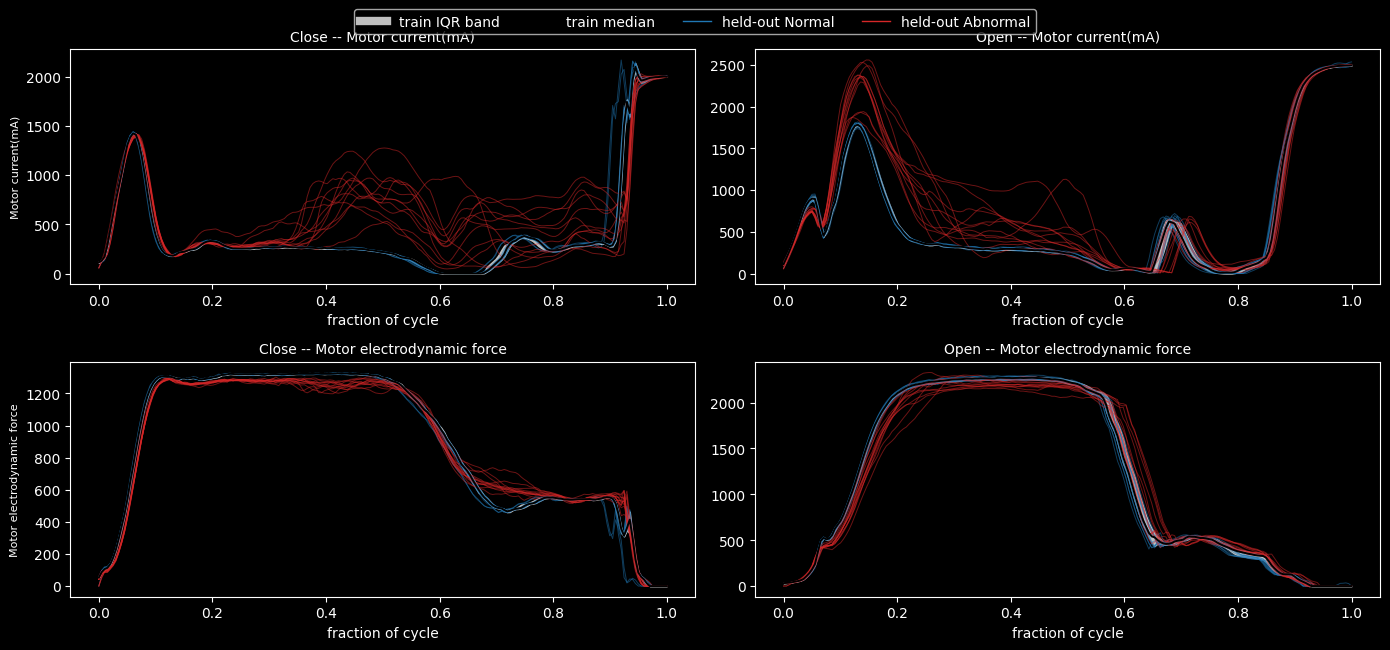

In [13]:
held_out = np.sort(np.concatenate([splits["tune"], splits["val"]]))
z_all, z_cycles, z_ops = residuals_for(data, held_out, templates)
z_status = truth.loc[z_cycles].to_numpy()
profiles_all, _ = cycle_profiles(data, held_out)

STATUS_COLORS = {STATUS_NORMAL: "tab:blue", STATUS_ABNORMAL: "tab:red"}


def plot_templates(channel_names=PROFILE_COLS, max_per_status=12):
    fig, axes = plt.subplots(len(channel_names), 2, figsize=(14, 3.2 * len(channel_names)),
                             squeeze=False)
    for r, channel in enumerate(channel_names):
        c = PROFILE_COLS.index(channel)
        for col, op in enumerate(["Close", "Open"]):
            ax = axes[r, col]
            t = templates[op]
            ax.fill_between(PHASE, t["q25"][:, c], t["q75"][:, c], color="0.75",
                            label="train IQR", zorder=1)
            ax.plot(PHASE, t["median"][:, c], color="black", lw=1.4, label="median", zorder=3)
            for status in [STATUS_NORMAL, STATUS_ABNORMAL]:
                m = (z_status == status) & (z_ops == op)
                for profile in profiles_all[m][:max_per_status]:
                    ax.plot(PHASE, profile[:, c], color=STATUS_COLORS[status],
                            lw=0.7, alpha=0.5, zorder=2)
            ax.set_title(f"{op} -- {channel}", fontsize=10)
            ax.set_xlabel("fraction of cycle")
            if col == 0:
                ax.set_ylabel(channel, fontsize=8)
    handles = [plt.Line2D([], [], color="0.75", lw=6, label="train IQR band"),
               plt.Line2D([], [], color="black", lw=1.4, label="train median"),
               plt.Line2D([], [], color="tab:blue", lw=1, label="held-out Normal"),
               plt.Line2D([], [], color="tab:red", lw=1, label="held-out Abnormal")]
    fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
    fig.tight_layout()
    return fig


plot_templates()
plt.show()

## 3. The residual profiles

`|z|` against phase, one line per held-out cycle. This is the plot that decides
whether shift tolerance is needed:

- residual **concentrated in narrow spikes at steep edges**, present in blue as well
  as red → misalignment, and a bounded-shift minimum is worth adding;
- residual **spread over a broad stretch of the cycle**, red well above blue → real
  difference, and the current alignment is good enough.

The lower panels show the median across cycles of each status, which is the same
comparison without 35 overlapping lines.

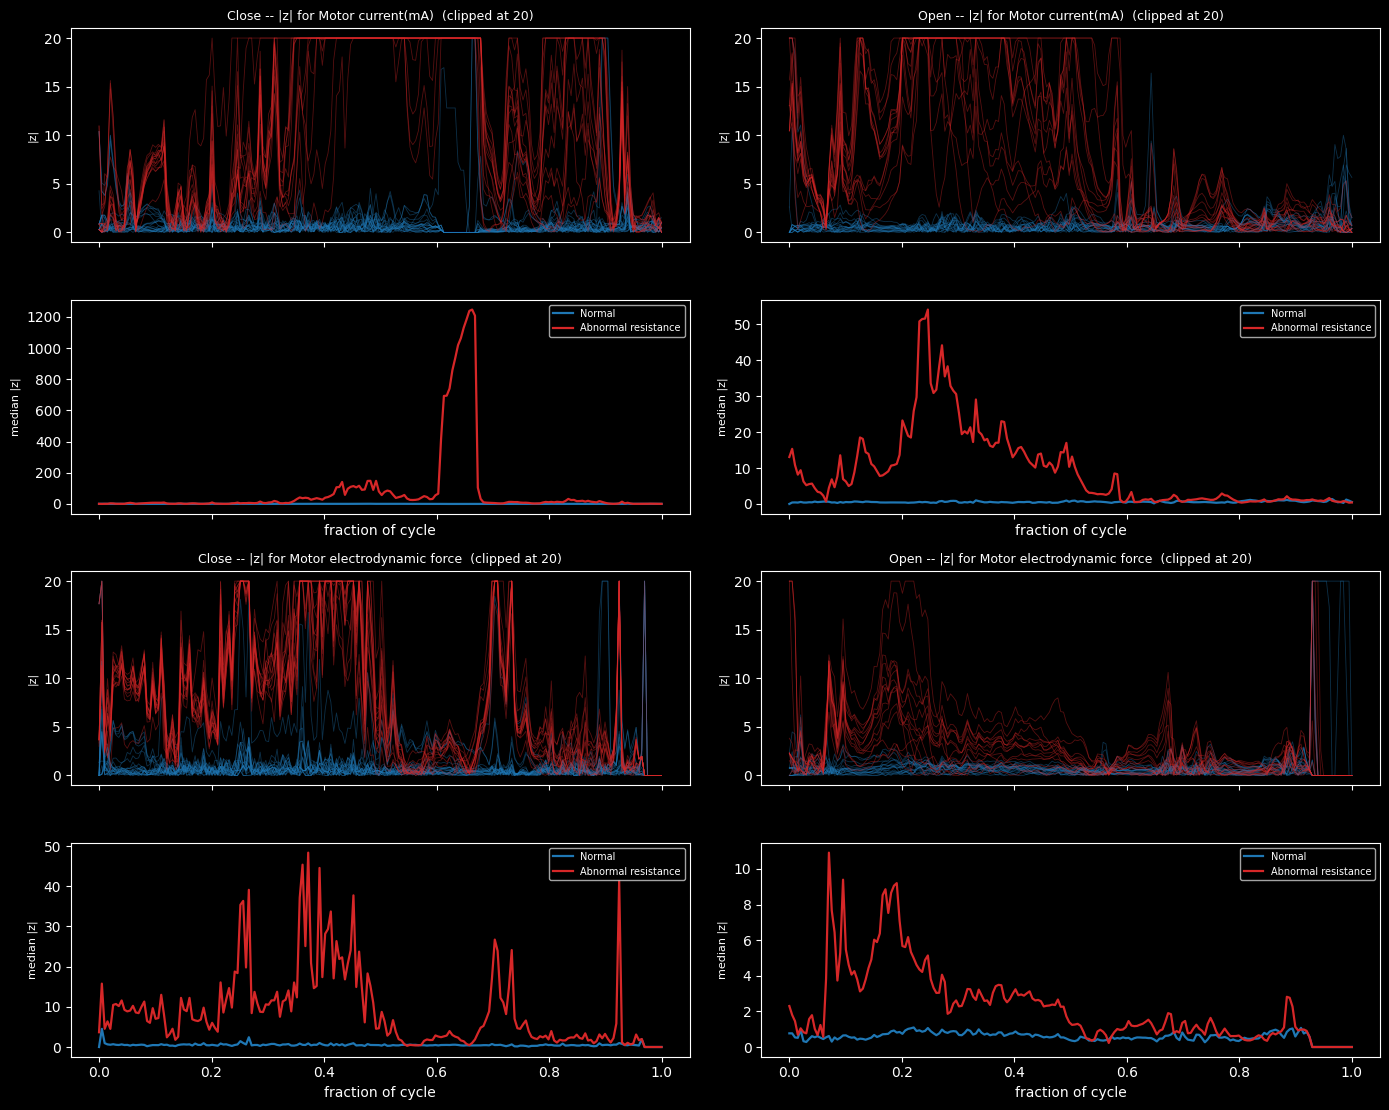

In [14]:
def plot_residuals(channel_names=PROFILE_COLS, clip=20):
    n = len(channel_names)
    fig, axes = plt.subplots(2 * n, 2, figsize=(14, 2.8 * 2 * n), squeeze=False,
                             sharex=True)
    for r, channel in enumerate(channel_names):
        c = PROFILE_COLS.index(channel)
        for col, op in enumerate(["Close", "Open"]):
            ax, ax_med = axes[2 * r, col], axes[2 * r + 1, col]
            for status in [STATUS_NORMAL, STATUS_ABNORMAL]:
                m = (z_status == status) & (z_ops == op)
                curves = np.abs(z_all[m][:, :, c])
                for curve in curves:
                    ax.plot(PHASE, np.clip(curve, 0, clip), color=STATUS_COLORS[status],
                            lw=0.6, alpha=0.4)
                if len(curves):
                    ax_med.plot(PHASE, np.median(curves, axis=0),
                                color=STATUS_COLORS[status], lw=1.6, label=status)
            ax.set_title(f"{op} -- |z| for {channel}  (clipped at {clip})", fontsize=9)
            ax.set_ylabel("|z|", fontsize=8)
            ax_med.set_ylabel("median |z|", fontsize=8)
            ax_med.set_xlabel("fraction of cycle")
            ax_med.legend(fontsize=7)
    fig.tight_layout()
    return fig


plot_residuals()
plt.show()

In [15]:
# How concentrated is each cycle's residual? A cycle whose |z| is driven by a few
# phase points looks like misalignment; one spread over many points looks like a
# genuine departure. Reported as the share of total |z| held by the worst 5% of
# phase points.
def concentration(z, channel=0, top_frac=0.05):
    curves = np.abs(z[:, :, channel])
    k = max(1, int(round(top_frac * curves.shape[1])))
    top = np.sort(curves, axis=1)[:, -k:].sum(axis=1)
    return top / np.maximum(curves.sum(axis=1), 1e-12)


rows = []
for c, channel in enumerate(PROFILE_COLS):
    for op in ["Close", "Open"]:
        for status in [STATUS_NORMAL, STATUS_ABNORMAL]:
            m = (z_status == status) & (z_ops == op)
            rows.append({"channel": channel, "operation": op, "status": status,
                         "median |z|": np.median(np.abs(z_all[m][:, :, c])),
                         "mean |z|": np.abs(z_all[m][:, :, c]).mean(),
                         "top-5% share": concentration(z_all[m], c).mean()})
print(pd.DataFrame(rows).to_string(index=False))

                   channel operation              status  median |z|  mean |z|  top-5% share
         Motor current(mA)     Close              Normal    0.438347  0.788542      0.243203
         Motor current(mA)     Close Abnormal resistance    8.519196 82.577634      0.583702
         Motor current(mA)      Open              Normal    0.533278  0.735203      0.219891
         Motor current(mA)      Open Abnormal resistance    3.782574 10.138597      0.259141
Motor electrodynamic force     Close              Normal    0.471166  1.007707      0.334294
Motor electrodynamic force     Close Abnormal resistance    6.035260  9.302960      0.232274
Motor electrodynamic force      Open              Normal    0.554936  0.838295      0.253666
Motor electrodynamic force      Open Abnormal resistance    1.452808  2.550466      0.224080


## 4. From residuals to a decision

One scalar per cycle, one threshold per operation — two numbers in the whole model.
The template is fitted on normal cycles only, so the abnormal cycles are used for
nothing except placing those two thresholds. That keeps it a one-class detector:
nothing has learned this particular fault's signature, which is what the info kit's
"scarce fault samples" problem asks for.

**A simplification worth knowing.** Because segmentation is exact and we emit one
prediction per detected cycle, every prediction either matches its own true segment
with IoU 1.0 (right label) or cannot match at all (wrong label). So
`n_true = n_pred = N`, `total_iou = (cycles labelled correctly)`, and the
IoU-weighted F1 collapses to **plain cycle accuracy**. Two consequences: the metric
decomposes additively over cycles, so each operation's threshold can be chosen
independently without approximating anything; and `score_predictions` stays the
authority, but no longer needs to be inside the inner loop of a sweep.

In [16]:
# ---- scoring one split against the answer key ------------------------------

def score_split(data, answer, cycle_ids, labels):
    """Run `score_predictions` over one split only.

    The answer frame is subset to the same cycles, otherwise every cycle outside
    the split counts as a miss and the recall term is meaningless. Cycles with no
    label default to Normal rather than being dropped, so the prediction count
    stays honest.
    """
    cycle_ids = np.sort(np.asarray(cycle_ids))
    rows = data[data["cycle"].isin(cycle_ids)].copy()
    rows["label"] = rows["cycle"].map(lambda c: labels.get(c, STATUS_NORMAL))
    return score_predictions(rows, answer.iloc[cycle_ids - 1])


# ---- candidate cycle statistics --------------------------------------------

def _top_fraction_mean(values, fraction):
    """Mean of the largest `fraction` of values along the phase axis."""
    k = max(1, int(round(fraction * values.shape[0])))
    return np.sort(values, axis=0)[-k:].mean(axis=0)


# Each takes one cycle's residual (n_phase, n_channels) and returns one value per
# channel. All are label-free -- none of them needs to know where the abnormal
# cycles differ, so none can leak the labels into the score definition.
SCORE_METHODS = {
    "mean_z2":     lambda z: (z ** 2).mean(axis=0),
    "p95_abs":     lambda z: np.percentile(np.abs(z), 95, axis=0),
    "top10_z2":    lambda z: _top_fraction_mean(z ** 2, 0.10),
    "top05_z2":    lambda z: _top_fraction_mean(z ** 2, 0.05),
}

# How the per-channel values become one number. "max" lets either channel raise
# the alarm on its own; "mean" requires agreement and lets the weaker channel
# dilute the stronger one (motor current is much the stronger on Close).
COMBINERS = {
    "max": lambda v: v.max(axis=-1),
    "mean": lambda v: v.mean(axis=-1),
    **{f"only:{c}": (lambda v, i=i: v[..., i]) for i, c in enumerate(PROFILE_COLS)},
}


def cycle_scores_from_residuals(z, method="top10_z2", combine="max"):
    """(n_cycles, n_phase, n_channels) residuals -> one score per cycle."""
    per_channel = np.stack([SCORE_METHODS[method](z[i]) for i in range(len(z))])
    return COMBINERS[combine](per_channel)


# ---- thresholds ------------------------------------------------------------

def fit_thresholds(scores, cycles, operations, truth):
    """One threshold per operation, chosen to maximise cycle accuracy.

    Candidates are the midpoints between adjacent observed scores, so the sweep
    is exhaustive over distinct decisions rather than over an arbitrary
    percentile grid -- with 35 cycles there is no reason to approximate.
    """
    labels = (truth.loc[cycles].to_numpy() == STATUS_ABNORMAL)
    thresholds = {}
    for op in np.unique(operations):
        m = operations == op
        s, y = scores[m], labels[m]
        order = np.sort(np.unique(s))
        candidates = np.concatenate([[order[0] - 1],
                                     (order[:-1] + order[1:]) / 2,
                                     [order[-1] + 1]])
        accuracy = [((s >= t) == y).mean() for t in candidates]
        thresholds[op] = float(candidates[int(np.argmax(accuracy))])
    return thresholds


def predict_status(scores, operations, thresholds):
    """Score + per-operation threshold -> {cycle position: status}. Needs no labels,
    so this is exactly what runs on Test."""
    return np.where(scores >= np.array([thresholds[op] for op in operations]),
                    STATUS_ABNORMAL, STATUS_NORMAL)


def evaluate_config(data, answer, templates, truth, tune_cycles, val_cycles,
                    method="top10_z2", combine="max"):
    """Fit thresholds on tune, report the official score on both splits."""
    out = {"method": method, "combine": combine}
    z_tune, c_tune, op_tune = residuals_for(data, tune_cycles, templates)
    s_tune = cycle_scores_from_residuals(z_tune, method, combine)
    thresholds = fit_thresholds(s_tune, c_tune, op_tune, truth)
    out["thresholds"] = thresholds

    for name, cycle_ids in [("tune", tune_cycles), ("val", val_cycles)]:
        z, c, op = residuals_for(data, cycle_ids, templates)
        s = cycle_scores_from_residuals(z, method, combine)
        status = predict_status(s, op, thresholds)
        result = score_split(data, answer, c, dict(zip(c, status)))
        out[name] = result["score"]
        out[f"{name}_errors"] = int(result["misses"])
    return out

### 4.1 Compare the candidate statistics

Selection is on `tune` only. The `val` column is printed for information — reading
it and then picking the best row would turn the held-out split into a second tuning
split.

In [17]:
rows = []
for method in SCORE_METHODS:
    for combine in ["max", "mean"] + [f"only:{c}" for c in PROFILE_COLS]:
        rows.append(evaluate_config(data, answer, templates, truth,
                                    splits["tune"], splits["val"],
                                    method=method, combine=combine))

comparison = pd.DataFrame(rows)[["method", "combine", "tune", "tune_errors",
                                 "val", "val_errors"]]
print(comparison.sort_values("tune", ascending=False).to_string(index=False))

best = comparison.loc[comparison["tune"].idxmax()]
METHOD, COMBINE = best["method"], best["combine"]
print(f"\nselected on tune: method={METHOD}  combine={COMBINE}")

  method                         combine     tune  tune_errors      val  val_errors
 mean_z2                             max 1.000000            0 0.914286           3
 mean_z2                            mean 1.000000            0 0.914286           3
 mean_z2          only:Motor current(mA) 1.000000            0 0.914286           3
 p95_abs          only:Motor current(mA) 1.000000            0 0.971429           1
top05_z2          only:Motor current(mA) 1.000000            0 0.914286           3
top10_z2          only:Motor current(mA) 1.000000            0 0.914286           3
top10_z2                            mean 1.000000            0 0.914286           3
top10_z2                             max 1.000000            0 0.914286           3
 p95_abs only:Motor electrodynamic force 0.971429            1 0.971429           1
 p95_abs                            mean 0.971429            1 1.000000           0
 p95_abs                             max 0.971429            1 0.971429     

### 4.2 The selected configuration

In [18]:
chosen = evaluate_config(data, answer, templates, truth,
                         splits["tune"], splits["val"], METHOD, COMBINE)
thresholds = chosen["thresholds"]
print(f"thresholds: {({k: round(v, 3) for k, v in thresholds.items()})}")
print(f"tune {chosen['tune']:.4f}   val {chosen['val']:.4f}")

z_val, c_val, op_val = residuals_for(data, splits["val"], templates)
s_val = cycle_scores_from_residuals(z_val, METHOD, COMBINE)
status_val = predict_status(s_val, op_val, thresholds)

print("\ncycle-level confusion (val):")
print(pd.crosstab(truth.loc[c_val].to_numpy(), status_val,
                  rownames=["true"], colnames=["predicted"]))

baseline = score_split(data, answer, splits["val"],
                       {c: STATUS_NORMAL for c in splits["val"]})
print(f"\nall-Normal baseline on val: {baseline['score']:.4f}")

thresholds: {'Close': 15172.476, 'Open': 66.41}
tune 1.0000   val 0.9143

cycle-level confusion (val):
predicted            Abnormal resistance  Normal
true                                            
Abnormal resistance                   12       3
Normal                                 0      20

all-Normal baseline on val: 0.5714


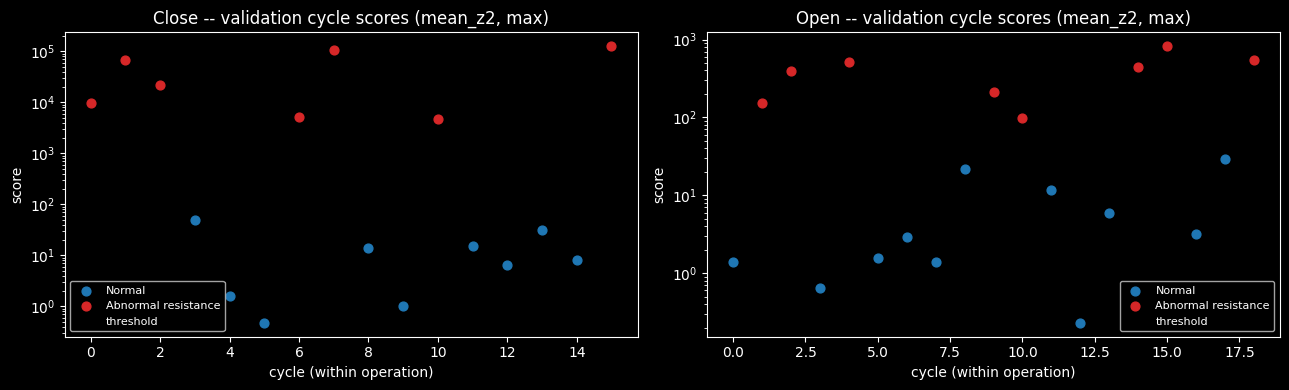

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, op in zip(axes, ["Close", "Open"]):
    m = op_val == op
    for status, color in STATUS_COLORS.items():
        sel = m & (truth.loc[c_val].to_numpy() == status)
        ax.scatter(np.arange(m.sum())[truth.loc[c_val].to_numpy()[m] == status],
                   s_val[sel], color=color, label=status, s=40)
    ax.axhline(thresholds[op], color="black", ls="--", lw=1, label="threshold")
    ax.set_yscale("log")
    ax.set_title(f"{op} -- validation cycle scores ({METHOD}, {COMBINE})")
    ax.set_xlabel("cycle (within operation)")
    ax.set_ylabel("score")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 4.3 Is the IQR floor doing the work?

`IQR_FLOOR_FRAC` governs how loudly the zero-variance phases speak — the stretches
where normal motor current sits at exactly 0 mA. Those carry real signal, but if
the score collapses when they're damped, then what the model has really learned is
"did the current return to zero", and that is worth knowing before shipping it.

In [20]:
rows = []
for floor in [0.01, 0.05, 0.2, 1.0]:
    trial_templates = {}
    operation_all = cycle_operation(data)
    for op in ["Close", "Open"]:
        ids = [c for c in splits["train"] if operation_all.loc[c] == op]
        profiles, _ = cycle_profiles(data, ids)
        trial_templates[op] = build_template(profiles, iqr_floor_frac=floor)
    result = evaluate_config(data, answer, trial_templates, truth,
                             splits["tune"], splits["val"], METHOD, COMBINE)
    rows.append({"iqr_floor_frac": floor, "tune": result["tune"], "val": result["val"]})
print(pd.DataFrame(rows).to_string(index=False))

 iqr_floor_frac     tune      val
           0.01 0.971429 0.800000
           0.05 1.000000 0.914286
           0.20 1.000000 0.971429
           1.00 1.000000 0.971429
